#### 1. import libraries

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
print('libararies has been Imported seccussfully!')

libararies has been Imported seccussfully!


#### 2. import dataset :

In [3]:
df = pd.read_csv('mpg.csv')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


#### 1. What are the discrete and continuous variables in this dataset :

In [32]:
discrete_variables = []
continuous_variables = []
for variable in df.columns :
    if df[variable].dtype == 'int64' or df[variable].dtype == 'object' or (df[variable].dropna() % 1 == 0).all()  :
        discrete_variables.append(variable)
    elif (df[variable].dropna() % 1 != 0).any() :
        continuous_variables.append(variable)
    else:
        print(variable,"is unknown")

print("Discrete:", discrete_variables)
print("Continuous:", continuous_variables)

Discrete: ['cylinders', 'horsepower', 'weight', 'model_year', 'origin', 'name']
Continuous: ['mpg', 'displacement', 'acceleration']


In [4]:
# check if the mpg values are discrete or continuous
fractional_values = df[df['mpg'] % 1 != 0]
print("\nHere are a few examples of values that do not end with a .0 suffix:")
fractional_values.head()



Here are a few examples of values that do not end with a .0 suffix:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
187,17.5,8,305.0,140.0,4215,13.0,76,usa,chevrolet chevelle malibu classic
189,15.5,8,304.0,120.0,3962,13.9,76,usa,amc matador
190,14.5,8,351.0,152.0,4215,12.8,76,usa,ford gran torino
194,22.5,6,232.0,90.0,3085,17.6,76,usa,amc hornet
196,24.5,4,98.0,60.0,2164,22.1,76,usa,chevrolet woody


In [ ]:
# print the total number of values with a non-zero decimal, which confirms the mpg values are continuous
print(f"Total number of mpg values with a non-zero decimal suffix is: {fractional_values.shape[0]} value.")

Total number of mpg values with a non-zero decimal suffix is: 139 value.


Conclusion:

"After analyzing the mpg (Miles Per Gallon) variable, we found that it is a continuous quantitative variable. Although some rows appear to contain discrete integers formatted with a .0 suffix, our analysis confirmed the presence of fractional values (such as 17.5 or 46.6), definitively proving its continuous nature. In the context of the dataset, this variable measures fuel efficiency; therefore, a higher mpg value indicates a vehicle that is more fuel-efficient and consumes less gas."

#### 2.2. What is the average? What does it actually represent? (be specific) :

In [ ]:
Mean_mgp = df['mpg'].mean()
print(f"mean gallon per Mile is :{Mean_mgp:.2f} mpg")


mean gallon per Mile is :23.51 mpg


#### 2.2. Draw the two relevant graphs for this variable : 

In [17]:
fractional = df[df['horsepower'] % 1 != 0]
print("\nHere are a few examples of values that do not end with a .0 suffix:")
fractional.head()


Here are a few examples of values that do not end with a .0 suffix:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,usa,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,europe,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,europe,renault 18i


In [ ]:
df["horsepower"].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [19]:
# print the total number of values with a non-zero decimal, which confirms the mpg values are continuous
print(f"Total number of mpg values with a non-zero decimal suffix is: {fractional.shape[0]} value.")


Total number of mpg values with a non-zero decimal suffix is: 6 value.


#### 3. Observe the evolution of car fuel consumption (mpg) in relation to horsepower :

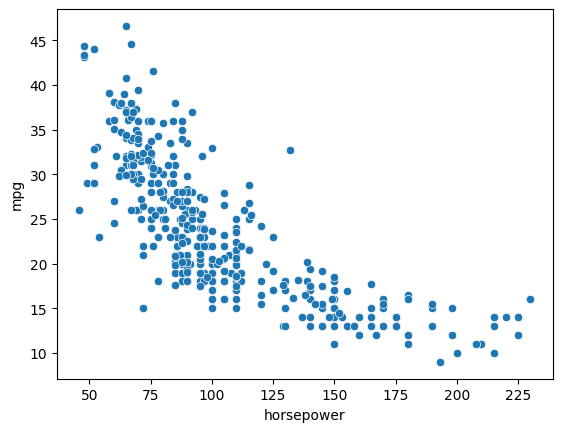

In [ ]:
sns.scatterplot(data=df, x='horsepower', y='mpg')

plt.xlabel("Horsepower (HP)")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Relationship between Horsepower and MPG")
plt.show()


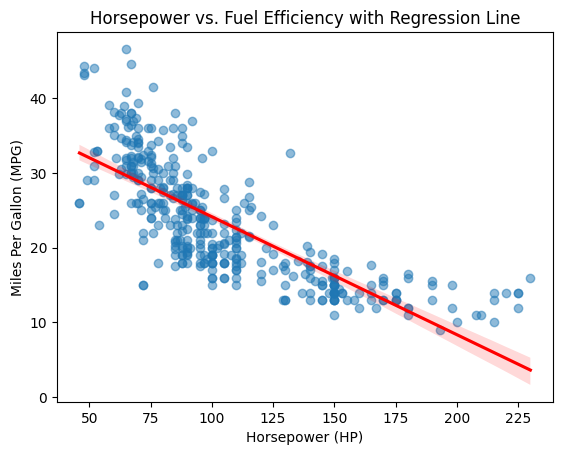

In [38]:
sns.regplot(data=df, 
            x='horsepower', 
            y='mpg', 
            line_kws={'color': 'red'}, 
            scatter_kws={'alpha': 0.5})

plt.xlabel("Horsepower (HP)")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Horsepower vs. Fuel Efficiency with Regression Line")
plt.show()

In [41]:
clean_df = df.dropna(subset=['horsepower', 'mpg'])

slope, intercept, r_value, p_value, std_err = stats.linregress(clean_df['horsepower'], clean_df['mpg'])
print(f"The slope of the regression line in MPG = f(HP) is : {slope:.4f}")
print(intercept)


The slope of the regression line in MPG = f(HP) is : -0.1578
39.93586102117047


*Conclusion: Horsepower vs. Fuel Efficiency*

Based on the scatter plot and the regression line, we can draw the following conclusions:

Strong Negative Correlation: There is a clear, strong inverse relationship between horsepower and fuel efficiency. As a vehicle's horsepower increases, its miles per gallon (MPG) consistently decreases.
Engineering Reality: This visually confirms the physical engineering principle that larger, more powerful engines require substantially more fuel to operate, resulting in lower fuel efficiency.
Non-Linear Tendency (Diminishing Returns): While the red linear regression line captures the overall declining trend, the data points themselves follow a slight curve. In the lower horsepower range (50-100 HP), small increases in power cause massive drops in MPG. However, at higher horsepower ranges (150+ HP), the drop in fuel efficiency begins to level out and flatten around 10 to 15 MPG.
Data Distribution: The densest clustering of data points exists between 60 and 110 horsepowers. This suggests that the majority of the vehicles in this dataset were built for the general consumer with lower horsepower and moderate-to-high fuel efficiency (18-35 MPG), while high-performance gas-guzzlers are less common outliers.


#### 4. Adding the model year variable :

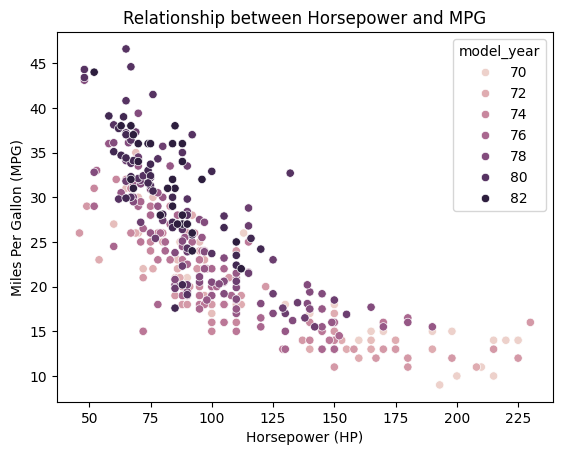

In [48]:
sns.scatterplot(data=df, x='horsepower', y='mpg', hue ="model_year")

plt.xlabel("Horsepower (HP)")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Relationship between Horsepower and MPG")
plt.show()


By adding model_year as a color dimension to our scatter plot, two major historical trends become immediately clear:

Overall Efficiency Improved Over Time: At almost any given horsepower level, the darker dots (newer models from the late '70s and early '80s) sit higher on the Y-axis than the lighter dots (older models). This proves that automotive engineering advanced, allowing newer cars to extract more MPG from the exact same amount of horsepower.
A Shift in Manufacturing Priorities: There is an almost complete absence of dark dots (newer cars) in the bottom-right corner (>150 HP). This indicates a massive shift in the automotive industry during this decade: manufacturers actively stopped building high-horsepower gas guzzlers and pivoted toward producing the highly efficient, lower-horsepower vehicles densely packed in the top-left corner.